---
## 1. Setup

In [1]:

import torch

if torch.cuda.is_available(): print(f"GPU: {torch.cuda.get_device_name(0)}")


GPU: Tesla T4


In [2]:
!pip install -q open_clip_torch tqdm matplotlib pillow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 24.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.6 MB/s eta 0:00:00


In [3]:


import os, json, random, shutil, time, math, gc, subprocess
import numpy as np
from pathlib import Path
from collections import defaultdict
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import open_clip

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")


Device: cuda


---
## 2. Configuration

In [4]:
!pip install gdown

import gdown


In [ ]:
DATA_DIR   = Path("/content/fashioniq")
IMAGE_DIR  = DATA_DIR / "images"
ANNO_DIR   = DATA_DIR / "annotations"
CATEGORIES = ["dress", "shirt", "toptee"]


CACHE_DIR  = DATA_DIR / "cache"
CKPT_DIR   = DATA_DIR / "checkpoints"
for d in [DATA_DIR, IMAGE_DIR, ANNO_DIR, CACHE_DIR, CKPT_DIR]:
    d.mkdir(parents=True, exist_ok=True)
#This is the public drive that has all the extracted features
#from clip and dinov2 and also the best model weights
folder_url = "https://drive.google.com/drive/folders/1N9Bt86Z2KxjtvSqOynnNUENadDx_6n9x"
gdown.download_folder(folder_url, output="/content/cs776_feature", quiet=False, use_cookies=False)

DRIVE_DIR = Path("/content/cs776_feature")
SAVE_TO_DRIVE   = False
LOAD_FROM_DRIVE = True

CLIP_MODEL    = "ViT-B-16"
CLIP_PRETRAIN = "laion2b_s34b_b88k"
CLIP_DIM      = 512
DINO_MODEL    = "dinov2_vits14"
DINO_DIM      = 384
DINO_PATCHES  = 256


# Training hyperparameters
NUM_EPOCHS    = 150
BATCH_SIZE    = 256
LEARNING_RATE = 1e-5
WEIGHT_DECAY  = 2e-5
WARMUP_EPOCHS = 5
T_0           = 15
T_MULT        = 2
NUM_WORKERS   = 0


#Image Preprocessing
TARGET_RATIO  = 1.25
INPUT_DIM     = 224




Retrieving folder contents


Processing file 1NpHiGB2oKuyMFjdZcSf9iahSdKiumn83 best_cdcir.pt
Processing file 1zkcAOu90hYdnJ3HYM5JTJmnIVhL2kB6z clip_cls_fashioniq.pt
Processing file 15EtWCiL34M2dx0rl79vM1KcQxNdy6R4N dino_patches_fashioniq.pt
Processing file 1vd71Tt-nEhwyUVCjSgz3zMtMcgbSZCNN text_cls_fashioniq.pt
Processing file 1jbazKnJAlYYyxars294PyW609dCpTe5K text_tokens_fashioniq.pt


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From (original): https://drive.google.com/uc?id=1NpHiGB2oKuyMFjdZcSf9iahSdKiumn83
From (redirected): https://drive.google.com/uc?id=1NpHiGB2oKuyMFjdZcSf9iahSdKiumn83&confirm=t&uuid=9be6f8e1-bd76-4dd1-b296-5253c4911aee
To: /content/cs776_feature/best_cdcir.pt
100%|██████████| 28.9M/28.9M [00:00<00:00, 85.6MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1zkcAOu90hYdnJ3HYM5JTJmnIVhL2kB6z
From (redirected): https://drive.google.com/uc?id=1zkcAOu90hYdnJ3HYM5JTJmnIVhL2kB6z&confirm=t&uuid=5475b4fb-867c-4065-8d8d-e2ecc3a2c7a6
To: /content/cs776_feature/clip_cls_fashioniq.pt
100%|██████████| 128M/128M [00:01<00:00, 76.0MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=15EtWCiL34M2dx0rl79vM1KcQxNdy6R4N
From (redirected): https://drive.google.com/uc?id=15EtWCiL34M2dx0rl79vM1KcQxNdy6R4N&confirm=t&uuid=e9838df1-74e9-4f82-8fdd-85724a59b8ab
To

---
## 3. Download Dataset

In [6]:

ANNO_BASE = "https://raw.githubusercontent.com/XiaoxiaoGuo/fashion-iq/master/captions"
SPLIT_BASE = "https://raw.githubusercontent.com/XiaoxiaoGuo/fashion-iq/master/image_splits"
ANNO_DIR.mkdir(parents=True, exist_ok=True)
for cat in CATEGORIES:
    for sp in ["train", "val"]:
        f = ANNO_DIR / f"cap.{cat}.{sp}.json"
        if not f.exists(): os.system(f'wget -q -O {f} {ANNO_BASE}/cap.{cat}.{sp}.json')
    for sp in ["train", "val", "test"]:
        f = ANNO_DIR / f"split.{cat}.{sp}.json"
        if not f.exists(): os.system(f'wget -q -O {f} {SPLIT_BASE}/split.{cat}.{sp}.json')



In [7]:


existing = list(IMAGE_DIR.glob("*.jpg")) + list(IMAGE_DIR.glob("*.png"))
if len(existing) > 10000:
    print(f"Images present: {len(existing)}")
else:
    !pip install -q kaggle
    if not os.path.exists(os.path.expanduser("~/.kaggle/kaggle.json")):
        from google.colab import files
        !mkdir -p ~/.kaggle && mv kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
    !kaggle datasets download -d hoangkim14/fashion-iq-dataset -p /content/kaggle_download
    !unzip -q -o /content/kaggle_download/fashion-iq-dataset.zip -d /content/kaggle_download/
    IMAGE_DIR.mkdir(parents=True, exist_ok=True)
    subprocess.run(f"find /content/kaggle_download -name '*.jpg' -exec mv {{}} {IMAGE_DIR}/ \\;", shell=True)
    subprocess.run(f"find /content/kaggle_download -name '*.png' -exec mv {{}} {IMAGE_DIR}/ \\;", shell=True)
    !rm -rf /content/kaggle_download
    print(f"{len(list(IMAGE_DIR.glob('*.*')))} images")




mv: cannot stat 'kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/hoangkim14/fashion-iq-dataset
License(s): other
100% 630M/630M [00:03<00:00, 196MB/s]

74381 images


---
## 4. Load Annotations

In [8]:

# Load Annotations

DATASET = "fashioniq"

def load_anno(d, cats, split):
    data = {}
    for c in cats:
        with open(d/f"cap.{c}.{split}.json") as f: caps=json.load(f)
        with open(d/f"split.{c}.{split}.json") as f: names=json.load(f)
        data[c] = {"captions":caps, "image_names":names}
    return data

train_data = load_anno(ANNO_DIR, CATEGORIES, "train")
val_data   = load_anno(ANNO_DIR, CATEGORIES, "val")

def find_img(img_id, img_dir):
    for ext in [".jpg",".png",".jpeg"]:
        p = img_dir / f"{img_id}{ext}"
        if p.exists(): return p
    return None

all_ids = set()
for sd in [train_data, val_data]:
    for c in CATEGORIES:
        all_ids.update(sd[c]["image_names"])
        for it in sd[c]["captions"]:
            all_ids.add(it["candidate"]); all_ids.add(it["target"])
ref_ids = set()
for sd in [train_data, val_data]:
    for c in CATEGORIES:
        for it in sd[c]["captions"]: ref_ids.add(it["candidate"])

available = sum(1 for i in all_ids if find_img(i, IMAGE_DIR))
print(f"IDs: {len(all_ids)} | Available: {available} | Refs: {len(ref_ids)}")
for n,sd in [("train",train_data),("val",val_data)]:
    print(f"  {n}: {sum(len(sd[c]['captions']) for c in CATEGORIES)} triplets")



IDs: 60033 | Available: 60033 | Refs: 16787
  train: 18000 triplets
  val: 6016 triplets


---
## 5. Load Models & Transforms

In [9]:
# This cell explain how the images were transformed (we follow the recommended way described in clip4cir) before passing through the models

class TargetPad:
    def __init__(self, ratio, dim):
        self.ratio = ratio
    def __call__(self, img):
        w,h = img.size; mx=max(w,h); td=int(mx*self.ratio)
        pad = Image.new("RGB",(td,td),(255,255,255))
        pad.paste(img,((td-w)//2,(td-h)//2)); return pad

clip_tf = transforms.Compose([
    TargetPad(TARGET_RATIO, INPUT_DIM),
    transforms.Resize(INPUT_DIM, interpolation=transforms.InterpolationMode.BICUBIC),
    transforms.CenterCrop(INPUT_DIM), transforms.ToTensor(),
    transforms.Normalize((0.48145466,0.4578275,0.40821073),(0.26862954,0.26130258,0.27577711))])

dino_tf = transforms.Compose([
    TargetPad(TARGET_RATIO, INPUT_DIM),
    transforms.Resize(INPUT_DIM, interpolation=transforms.InterpolationMode.BICUBIC),
    transforms.CenterCrop(INPUT_DIM), transforms.ToTensor(),
    transforms.Normalize((0.485,0.456,0.406),(0.229,0.224,0.225))])

clip_model, _, _ = open_clip.create_model_and_transforms(CLIP_MODEL, pretrained=CLIP_PRETRAIN)
clip_model = clip_model.to(DEVICE).eval()
tokenizer = open_clip.get_tokenizer(CLIP_MODEL)


dinov2 = torch.hub.load("facebookresearch/dinov2", DINO_MODEL, trust_repo=True)
dinov2 = dinov2.to(DEVICE).eval()


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


open_clip_model.safetensors:   0%|          | 0.00/599M [00:00<?, ?B/s]

Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to /root/.cache/torch/hub/main.zip


/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vits14/dinov2_vits14_pretrain.pth" to /root/.cache/torch/hub/checkpoints/dinov2_vits14_pretrain.pth


100%|██████████| 84.2M/84.2M [00:00<00:00, 233MB/s]


---
## 6. Feature Extraction

**4 pre-computed caches:**
1. CLIP CLS (512-d) — ALL images
2. DINOv2 patches (256×768) — reference images only
3. CLIP text [E0S] (512-d) — all unique captions
4. CLIP token Features (77×512)


In [10]:
# Free models from GPU
clip_model = clip_model.cpu()
dinov2 = dinov2.cpu()
del dinov2; gc.collect(); torch.cuda.empty_cache()


In [11]:
import torch, gc
from pathlib import Path

CACHE_DRIVE_DIR = Path("/content/cs776_feature")
DATASET = "fashioniq"

dino_patches_cache = torch.load(CACHE_DRIVE_DIR / f"dino_patches_{DATASET}.pt",
                                map_location='cpu', weights_only=False)
for k in list(dino_patches_cache.keys()):
    dino_patches_cache[k] = dino_patches_cache[k].half().to(DEVICE)
gc.collect()

text_token_cache = torch.load(CACHE_DRIVE_DIR / f"text_tokens_{DATASET}.pt",
                              map_location='cpu', weights_only=False)
for k in list(text_token_cache.keys()):
    text_token_cache[k] = text_token_cache[k].half().to(DEVICE)
gc.collect()

#
clip_features = torch.load(CACHE_DRIVE_DIR / f"clip_cls_{DATASET}.pt",
                           map_location='cpu', weights_only=False)
for k in list(clip_features.keys()):
    clip_features[k] = clip_features[k].float().to(DEVICE)
gc.collect()

text_cls_cache = torch.load(CACHE_DRIVE_DIR / f"text_cls_{DATASET}.pt",
                            map_location='cpu', weights_only=False)
for k in list(text_cls_cache.keys()):
    text_cls_cache[k] = text_cls_cache[k].float().to(DEVICE)
gc.collect()
torch.cuda.empty_cache()

print(f"CLIP:{len(clip_features)} | patches:{len(dino_patches_cache)}"
      f" | text tokens:{len(text_token_cache)} | text cls:{len(text_cls_cache)}")
print(f"GPU mem: {torch.cuda.memory_allocated()/1e9:.2f} GB")


CLIP:60033 | patches:16787 | text tokens:56969 | text cls:56969
GPU mem: 8.03 GB


---
## 7. Dataset

In [12]:

class FashionIQDataset(Dataset):
    def __init__(self, annotations, clip_cache,
                  patch_cache, text_token_cache, text_cls_cache, split="train"):
        self.clip_cache = clip_cache
        self.patch_cache = patch_cache
        self.text_token_cache = text_token_cache
        self.text_cls_cache = text_cls_cache
        self.triplets = []
        for cat, data in annotations.items():
            for item in data["captions"]:
                rid, tid = item["candidate"], item["target"]
                c1, c2 = item["captions"][0], item["captions"][1]
                combined = c1 + " and " + c2
                if not (rid in clip_cache and tid in clip_cache and
                        rid in patch_cache): continue
                if split == "train":
                    for cap in [c1, c2, combined]:

                        if cap in text_token_cache and cap in text_cls_cache:
                            self.triplets.append({"rid":rid,"tid":tid,"cap":cap,"cat":cat})
                else:
                    if combined in text_token_cache and combined in text_cls_cache:
                        self.triplets.append({"rid":rid,"tid":tid,"cap":combined,"cat":cat})


    def __len__(self): return len(self.triplets)
    def __getitem__(self, idx):
        t = self.triplets[idx]
        return {
            "ref_clip":     self.clip_cache[t["rid"]],
            "tgt_clip":     self.clip_cache[t["tid"]],
            "ref_patches":  self.patch_cache[t["rid"]],
            "text_tokens":  self.text_token_cache[t["cap"]],   # [77, 512]
            "text_cls":     self.text_cls_cache[t["cap"]],     # [512]
        }
CIRDataset = FashionIQDataset





---
## 8. Model Architecture




In [13]:
NUM_LAYERS  = 1
NUM_HEADS   = 8
FFN_MULT    = 4
DROPOUT     = 0.05


class TextQueryDINOLayer(nn.Module):
    def __init__(self, text_dim=512, dino_dim=384, num_heads=8,
                 ffn_mult=4, dropout=0.1):
        super().__init__()
        # Cross-attention
        self.xa_norm = nn.LayerNorm(text_dim)

        self.cross_attn = nn.MultiheadAttention(
            embed_dim=text_dim, num_heads=num_heads,
            kdim=dino_dim, vdim=dino_dim,
            dropout=dropout, batch_first=True)

        self.xa_gate = nn.Parameter(torch.tensor(0.65))


        self.ff_norm = nn.LayerNorm(text_dim)

        self.ffn = nn.Sequential(
            nn.Linear(text_dim, text_dim * ffn_mult),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(text_dim * ffn_mult, text_dim),
            nn.Dropout(dropout))

    def forward(self, text_tokens, dino_patches, return_attn=False):
        # Cross attention: text token features -> queries DINOv2 patches -> Key and Yalue
        h = self.xa_norm(text_tokens)

        if return_attn:
            xa_out, attn_w = self.cross_attn(
                h, dino_patches, dino_patches,
                need_weights=True, average_attn_weights=True)
        else:
            xa_out = self.cross_attn(
                h, dino_patches, dino_patches,
                need_weights=False)[0]
            attn_w = None

        text_tokens = text_tokens + torch.tanh(self.xa_gate) * xa_out

        # FFN
        text_tokens = text_tokens + self.ffn(self.ff_norm(text_tokens))

        if return_attn:
            return text_tokens, attn_w
        return text_tokens


class TextQueryDINOCombiner(nn.Module):
    def __init__(self, clip_dim=512, dino_dim=384, num_heads=8,
                 num_layers=2, ffn_mult=4, dropout=0.1,):
        super().__init__()
        fused_dim = clip_dim * 3

        self.layers = nn.ModuleList([
            TextQueryDINOLayer(clip_dim, dino_dim, num_heads, ffn_mult, dropout)
            for _ in range(num_layers)
        ])

        # Attention pooler
        self.pool_query = nn.Parameter(torch.randn(1, 1, clip_dim) * 0.02)
        self.pool_attn  = nn.MultiheadAttention(
            clip_dim, num_heads, dropout=dropout, batch_first=True)
        self.pool_norm  = nn.LayerNorm(clip_dim)



        # Three way fusion
        self.fusion = nn.Sequential(
            nn.Linear(fused_dim, clip_dim * 2), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(clip_dim * 2, clip_dim))

        self.gate = nn.Sequential(
            nn.Linear(fused_dim, clip_dim), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(clip_dim, 1))

        nn.init.constant_(self.gate[-1].bias, -1.0)


        self.pooled_aux_proj = nn.Linear(clip_dim, clip_dim)

    def forward(self, text_tokens, dino_patches, ref_clip, text_cls, return_attn=False):
        attn_maps = []
        for layer in self.layers:
            if return_attn:
                text_tokens, aw = layer(text_tokens, dino_patches, return_attn=True)
                attn_maps.append(aw)
            else:
                text_tokens = layer(text_tokens, dino_patches)

        B = text_tokens.shape[0]
        pq = self.pool_query.expand(B, -1, -1)
        pooled, _ = self.pool_attn(pq, text_tokens, text_tokens)
        pooled = self.pool_norm(pooled).squeeze(1)       # [B, 512]


        cat    = torch.cat([ref_clip, text_cls, pooled], dim=-1)
        output = self.fusion(cat)
        lam    = torch.sigmoid(self.gate(cat))
        # print(lam)
        text_cls = F.normalize(text_cls, dim=-1)
        output = F.normalize(output, dim=-1)
        composed = lam * text_cls + (1 - lam) * output
        composed = F.normalize(composed, dim=-1)


        # FOr additional Loss
        pooled_out = F.normalize(self.pooled_aux_proj(pooled), dim=-1)

        if return_attn:
            return composed, pooled_out, attn_maps
        return composed, pooled_out





combiner = TextQueryDINOCombiner(
    clip_dim=CLIP_DIM, dino_dim=DINO_DIM, num_heads=NUM_HEADS,
    num_layers=NUM_LAYERS, ffn_mult=FFN_MULT, dropout=DROPOUT,

).to(DEVICE)



c_p = sum(p.numel() for p in combiner.parameters() if p.requires_grad)


print(f"TOTAL trainable (TQDKV + fusion): {(c_p)/1e6:.2f}M params")



TOTAL trainable (TQDKV + fusion): 7.22M params


---
## 9. Loss & Optimizer

In [14]:

# Loss: Symmetric InfoNCE + Optimizer

train_ds = CIRDataset(train_data, clip_features,
                       dino_patches_cache, text_token_cache, text_cls_cache, split="train")
val_ds   = CIRDataset(val_data,   clip_features,
                       dino_patches_cache, text_token_cache, text_cls_cache, split="val")

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=False, drop_last=True)



class ComposedRetrievalLoss(nn.Module):
    def __init__(self, init_temp=0.07, aux_w=0.4):
        """
        aux_w:     weight for pooled auxiliary loss (start high ~0.4, decay to 0.2)

        """
        super().__init__()
        self.logit_scale = nn.Parameter(torch.log(torch.tensor(1.0 / init_temp)))
        self.aux_w       = aux_w


    def _infonce(self, q, k, scale):
        """Symmetric InfoNCE with label smoothing."""

        logits = scale * q @ k.T

        labels = torch.arange(len(q), device=q.device)
        return (F.cross_entropy(logits, labels, label_smoothing=0.1) +
                F.cross_entropy(logits.T, labels, label_smoothing=0.1)) * 0.5

    def forward(self, composed, pooled_out, tgt_unified, attn_maps=None):
        scale = self.logit_scale.clamp(-4.6, 3.7).exp()

        loss_main = self._infonce(composed,   tgt_unified, scale)
        loss_aux  = self._infonce(pooled_out, tgt_unified, scale)


        return loss_main + self.aux_w * loss_aux


loss_fn = ComposedRetrievalLoss(init_temp=0.07, aux_w=0.4).to(DEVICE)


ema_decay = 0.998
ema_combiner = {k: v.clone() for k, v in combiner.state_dict().items()}

@torch.no_grad()
def update_ema(ema_dict, model, decay=0.998):
    for k, v in model.state_dict().items():
        ema_dict[k].mul_(decay).add_(v, alpha=1 - decay)

# Separate param groups
gate_params         = []
other_combiner_params = []

for name, p in combiner.named_parameters():
    if 'gate' in name:
        gate_params.append(p)
    else:
        other_combiner_params.append(p)

all_params = [
    {'params': other_combiner_params,          'lr': LEARNING_RATE},
    {'params': gate_params,                    'lr': LEARNING_RATE * 5},
    {'params': list(loss_fn.parameters()),     'lr': LEARNING_RATE *5},
]

optimizer = torch.optim.AdamW(
    all_params,
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

all_param_list = [p for group in optimizer.param_groups for p in group['params']]

steps_per_epoch = len(train_loader)
total_steps     = steps_per_epoch * NUM_EPOCHS


scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=[
        LEARNING_RATE,          # other combiner params
        LEARNING_RATE * 5,      # gate params
        LEARNING_RATE *5,    # loss_fn / temperature
    ],
    steps_per_epoch=steps_per_epoch,
    epochs=NUM_EPOCHS,
    pct_start=0.20,             # 20% warmup
    div_factor=20,              # start at max_lr/20
    final_div_factor=1000,      # end at max_lr/1000
    anneal_strategy='cos',
)


---
## 10. Evaluation

In [15]:


@torch.no_grad()
def build_gallery(clip_cache, device, bs=512):
    """Build and return (ids, feats) where feats are L2-normalized CLIP CLS."""
    ids = list(clip_cache.keys())
    feats = []
    for s in range(0, len(ids), bs):
        bid = ids[s:s + bs]
        gc = torch.stack([clip_cache[i] for i in bid]).to(device)
        feats.append(F.normalize(gc, dim=-1).cpu())
    return ids, torch.cat(feats, 0)


@torch.no_grad()
def _run_queries_batched(combiner, items, clip_cache, patch_cache,
                          text_token_cache, text_cls_cache, device, bs=64):
    """
    Build query embeddings in batches.
    Returns list of (composed [D],) one per valid item, and list of valid items.
    """
    valid, composed_list = [], []
    buf_txt, buf_pat, buf_rc, buf_tcls, buf_meta = [], [], [], [], []

    def flush():
        if not buf_txt:
            return
        txt  = torch.stack(buf_txt).to(device)
        pat  = torch.stack(buf_pat).to(device)
        rc   = torch.stack(buf_rc).to(device)
        tcls = torch.stack(buf_tcls).to(device)

        composed, _ = combiner(txt, pat, rc, tcls)
        for i, c in enumerate(composed):
            composed_list.append(c.cpu())
            valid.append(buf_meta[i])
        buf_txt.clear(); buf_pat.clear()
        buf_rc.clear(); buf_tcls.clear(); buf_meta.clear()

    for item in items:
        rid, tid, cap = item
        buf_txt.append(text_token_cache[cap].float())
        buf_pat.append(patch_cache[rid].float())
        buf_rc.append(clip_cache[rid])
        buf_tcls.append(text_cls_cache[cap])
        buf_meta.append((rid, tid))
        if len(buf_txt) == bs:
            flush()
    flush()

    return valid, composed_list


@torch.no_grad()
def evaluate(combiner, clip_cache,
             patch_cache, text_token_cache, text_cls_cache,
             val_data, device, dataset_name,
             val_caps_raw=None, ks=(1, 5, 10, 50)):

    combiner.eval()

    results = {}

    per_cat = {}

    for cat in CATEGORIES:
        cat_gids = val_data[cat]["image_names"]

        cat_ids, cat_clip = [], []
        for gid in cat_gids:
            if gid in clip_cache:
                cat_ids.append(gid)
                cat_clip.append(clip_cache[gid])

        cat_feats = []
        for s in range(0, len(cat_ids), 512):
            gc = torch.stack(cat_clip[s:s + 512]).to(device)
            cat_feats.append(F.normalize(gc, dim=-1).cpu())
        cat_feats  = torch.cat(cat_feats, 0).to(device)
        cat_id2idx = {g: i for i, g in enumerate(cat_ids)}


        valid_items = []
        for item in val_data[cat]["captions"]:
            rid, tid = item["candidate"], item["target"]
            cap = item["captions"][0] + " and " + item["captions"][1]
            if (rid in clip_cache and rid in patch_cache
                    and cap in text_token_cache and cap in text_cls_cache
                    and tid in cat_id2idx):
                valid_items.append((rid, tid, cap))

        meta_list, composed_list = _run_queries_batched(
            combiner, valid_items, clip_cache, patch_cache,
            text_token_cache, text_cls_cache, device)

        ch = {k: 0 for k in ks}
        ct = 0

        for (rid, tid), q in zip(meta_list, composed_list):
            q    = q.to(device)
            sims = (q.unsqueeze(0) @ cat_feats.T).squeeze(0).clone()

            rank = sims.argsort(descending=True).cpu().tolist().index(cat_id2idx[tid])
            for k in ks:
                if rank < k:
                    ch[k] += 1
            ct += 1

        for k in ks:
            val = 100 * ch[k] / max(ct, 1)
            per_cat.setdefault(f"R@{k}", []).append(val)

        print(f"  {cat}: R@10={100*ch[10]/max(ct,1):.2f}%"
              f"  R@50={100*ch[50]/max(ct,1):.2f}%")

    for k in ks:
        results[f"R@{k}"] = float(np.mean(per_cat[f"R@{k}"]))

    return results




---
## 11. Training Loop

In [16]:


train_losses, val_r10s, lrs = [], [], []
best_r10    = 0.0
best_epoch  = 0
no_improve  = 0
patience    = 15
global_step = 0

scaler    = torch.amp.GradScaler('cuda')
GRAD_CLIP = 1.0




print(f"  Dataset : {DATASET.upper()}  |  Epochs : {NUM_EPOCHS}  |  BS : {BATCH_SIZE}")


for epoch in range(NUM_EPOCHS):
    combiner.train()
    ep_loss = 0.0
    t0      = time.time()

    for batch in tqdm(train_loader, desc=f"Ep {epoch+1}/{NUM_EPOCHS}", leave=False):
        #Load batch
        ref_clip    = batch["ref_clip"].to(DEVICE)
        tgt_clip    = batch["tgt_clip"].to(DEVICE)
        ref_patches = batch["ref_patches"].float().to(DEVICE)   # [B, 256, 384]
        text_tokens = batch["text_tokens"].float().to(DEVICE)   # [B, 77, 512]
        text_cls    = batch["text_cls"].float().to(DEVICE)      # [B, 512]



        #Forward
        with torch.amp.autocast('cuda'):
            target = F.normalize(tgt_clip, dim=-1)

            composed, pooled_out = combiner(
                text_tokens, ref_patches, ref_clip, text_cls)
            loss = loss_fn(
                composed.float(), pooled_out.float(),
                target.float())

        # Backward
        optimizer.zero_grad(set_to_none=True)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(all_param_list, GRAD_CLIP)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        # EMA update
        update_ema(ema_combiner, combiner, ema_decay)

        ep_loss     += loss.item()
        if epoch < 10:
            loss_fn.aux_w = 2.0
        elif epoch < 25:
            loss_fn.aux_w = 1.0
        else:
            loss_fn.aux_w = 0.2
        global_step += 1

    avg_loss = ep_loss / len(train_loader)
    cur_lr   = optimizer.param_groups[0]["lr"]
    train_losses.append(avg_loss)
    lrs.append(cur_lr)



    real_c = {k: v.clone() for k, v in combiner.state_dict().items()}
    combiner.load_state_dict(ema_combiner)
    # Evaluate
    metrics = evaluate(
        combiner,
        clip_features,
        dino_patches_cache, text_token_cache, text_cls_cache,
        val_data, DEVICE, DATASET,
        val_caps_raw=(None))


    combiner.load_state_dict(real_c)
    combiner.train()


    r10 = metrics["R@10"]
    r50 = metrics["R@50"]
    elapsed = time.time() - t0
    val_r10s.append(r10)

    extra = ""
    print(f"Ep {epoch+1:3d} | L={avg_loss:.4f} | R@10={r10:.2f}%{extra}"
          f" | R@50={r50:.2f}%{extra}| lr={cur_lr:.1e} ")

    # Checkpoint
    if r10 > best_r10:
        best_r10   = r10
        best_epoch = epoch + 1
        no_improve = 0
        torch.save({
            "combiner": ema_combiner,
            "loss_fn":  loss_fn.state_dict(),
            "epoch":    epoch + 1,
            "r10":      r10,
            "metrics":  metrics,
        }, "best_cdcir1.pt")
        print(f"-> Best R@10 = {r10:.2f}% saved (epoch {best_epoch})")


    else:
        no_improve += 1
        print(f"  (no improve {no_improve}/{patience})")
        if no_improve >= patience:
            print(f"\n  Early stop at epoch {epoch+1}")
            break

print(f"Best R@10 = {best_r10:.2f}%  @  epoch {best_epoch}")


  Dataset : FASHIONIQ  |  Epochs : 150  |  BS : 256


Ep 1/150:   0%|          | 0/210 [00:00<?, ?it/s]

  dress: R@10=7.19%  R@50=18.59%
  shirt: R@10=7.80%  R@50=15.21%
  toptee: R@10=9.33%  R@50=20.60%
Ep   1 | L=16.0808 | R@10=8.11% | R@50=18.13%| lr=5.3e-07 
-> Best R@10 = 8.11% saved (epoch 1)


Ep 2/150:   0%|          | 0/210 [00:00<?, ?it/s]

  dress: R@10=13.39%  R@50=28.85%
  shirt: R@10=14.38%  R@50=27.33%
  toptee: R@10=17.90%  R@50=35.34%
Ep   2 | L=15.5631 | R@10=15.22% | R@50=30.51%| lr=6.0e-07 
-> Best R@10 = 15.22% saved (epoch 2)


...

  dress: R@10=36.94%  R@50=59.69%
  shirt: R@10=37.78%  R@50=58.59%
  toptee: R@10=43.04%  R@50=65.12%
Ep  64 | L=2.4733 | R@10=39.25% | R@50=61.13%| lr=8.1e-06 
  (no improve 13/15)


Ep 65/150:   0%|          | 0/210 [00:00<?, ?it/s]

  dress: R@10=36.64%  R@50=59.59%
  shirt: R@10=37.78%  R@50=58.39%
  toptee: R@10=42.99%  R@50=65.07%
Ep  65 | L=2.4544 | R@10=39.14% | R@50=61.02%| lr=8.0e-06 
  (no improve 14/15)


Ep 66/150:   0%|          | 0/210 [00:00<?, ?it/s]

  dress: R@10=36.59%  R@50=59.44%
  shirt: R@10=37.54%  R@50=58.24%
  toptee: R@10=42.89%  R@50=65.17%
Ep  66 | L=2.4325 | R@10=39.00% | R@50=60.95%| lr=7.9e-06 
  (no improve 15/15)

  Early stop at epoch 66
Best R@10 = 39.54%  @  epoch 51


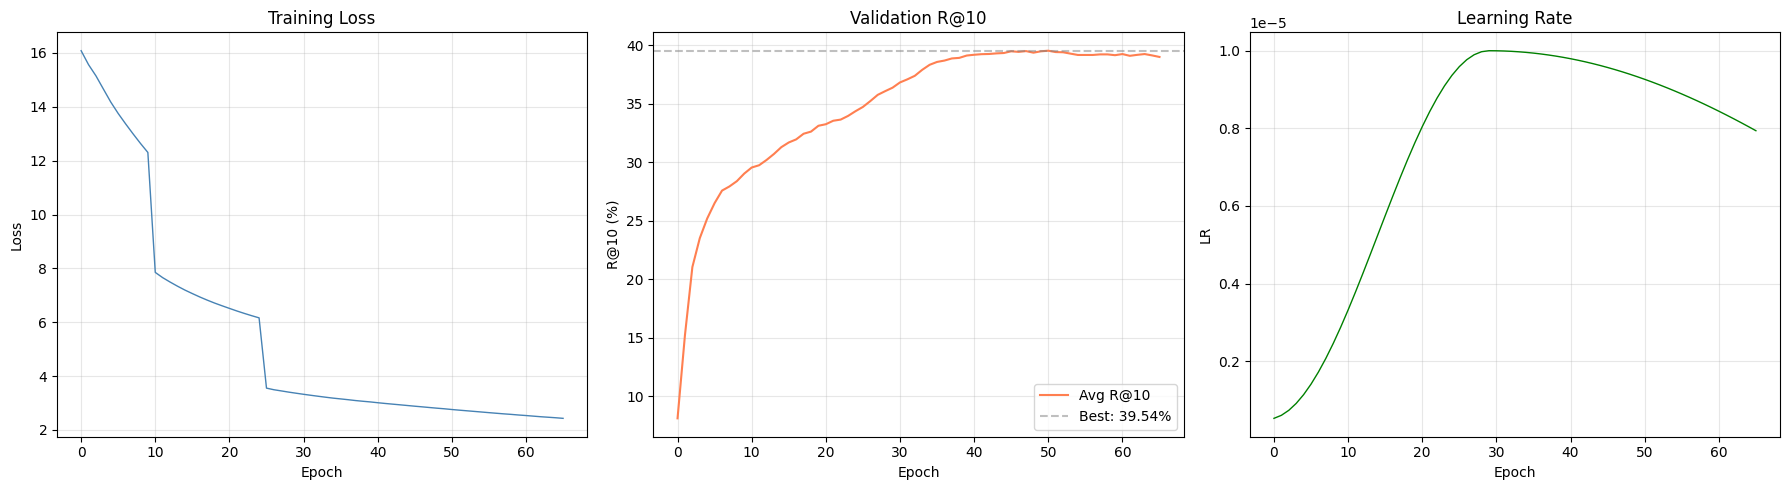

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(train_losses, color="steelblue", lw=1)
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].set_title("Training Loss"); axes[0].grid(alpha=0.3)

axes[1].plot(val_r10s, color="coral", lw=1.5, label="Avg R@10")
axes[1].axhline(best_r10, color="gray", ls="--", alpha=0.5, label=f"Best: {best_r10:.2f}%")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("R@10 (%)"); axes[1].set_title("Validation R@10")
axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(lrs, color="green", lw=1)
axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("LR"); axes[2].set_title("Learning Rate")
axes[2].grid(alpha=0.3)

plt.tight_layout(); plt.show()


---
## 12. Ablation: DINOv2 Contribution

In [18]:
import gc, torch

# Move text_tokens to CPU

for k in list(text_token_cache.keys()):
    text_token_cache[k] = text_token_cache[k].cpu()

ablation.clear() if 'ablation' in globals() else None

for name in ['sample_patches', 'p_mean', 'p_std', 'patch_experiments',
             'cache', 'm1', 'm2', 'comb']:
    if name in globals():
        del globals()[name]

for _ in range(3): gc.collect()
torch.cuda.empty_cache()
torch.cuda.synchronize()
print(f"GPU: {torch.cuda.memory_allocated()/1e9:.2f} GB")

GPU: 3.95 GB


  dress: R@10=37.48%  R@50=60.24%
  shirt: R@10=38.47%  R@50=59.22%
  toptee: R@10=44.72%  R@50=66.04%
  [1. Full Model] R@10 = 40.22%
  dress: R@10=33.32%  R@50=57.51%
  shirt: R@10=30.67%  R@50=51.13%
  toptee: R@10=35.75%  R@50=61.65%
  [2. Masked Dino Patches] R@10 = 33.24%
  dress: R@10=34.36%  R@50=56.87%
  shirt: R@10=33.91%  R@50=55.59%
  toptee: R@10=38.19%  R@50=61.91%
  [3. Mean Dino Patches] R@10 = 35.49%
  dress: R@10=32.03%  R@50=55.13%
  shirt: R@10=34.54%  R@50=54.02%
  toptee: R@10=39.47%  R@50=63.03%
  [4. Shuffled Dino Patches] R@10 = 35.35%
  dress: R@10=22.46%  R@50=42.14%
  shirt: R@10=27.28%  R@50=44.46%
  toptee: R@10=32.23%  R@50=53.44%
  [6. no_pooled] R@10 = 27.32%
  dress: R@10=35.20%  R@50=57.86%
  shirt: R@10=31.35%  R@50=51.82%
  toptee: R@10=40.85%  R@50=63.79%
  [7. no_ref_clip] R@10 = 35.80%

════════════════════════════════════════════════════════════
  Configuration                      R@10   Δ vs Full
───────────────────────────────────────────────

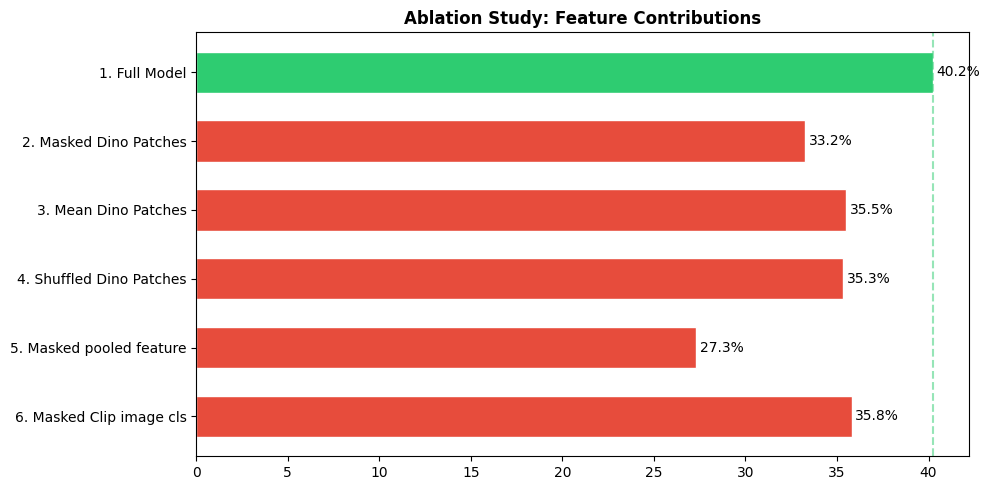

In [19]:
import copy, random
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

# loding the best weights
ckpt = torch.load("/content/cs776_feature/best_cdcir.pt", map_location=DEVICE, weights_only=False)
combiner.load_state_dict(ckpt["combiner"])
combiner.eval()
for p in combiner.parameters(): p.requires_grad_(False)

ablation = {}

def run_eval(comb, patch_cache_=None, label=""):
    pc = patch_cache_ if patch_cache_ is not None else dino_patches_cache
    with torch.no_grad():
        m = evaluate(
            comb, clip_features, pc, text_token_cache, text_cls_cache,
            val_data, DEVICE, DATASET, val_caps_raw=(val_caps_raw if DATASET == "cirr" else None)
        )
    print(f"  [{label}] R@10 = {m['R@10']:.2f}%")
    del comb
    gc.collect()
    torch.cuda.empty_cache()
    return m


def ablated_combiner(mask_ref_clip=False, mask_pooled=False, text_only=False):
    """Creates a copy of the combiner with specific internal features zeroed out."""
    model = copy.deepcopy(combiner)

    def custom_forward(text_tokens, dino_patches, ref_clip, text_cls, return_attn=False):
        tt, attn_maps = text_tokens, []
        for layer in model.layers:
            if return_attn:
                tt, aw = layer(tt, dino_patches, return_attn=True)
                attn_maps.append(aw)
            else:
                tt = layer(tt, dino_patches)

        B = tt.shape[0]
        pq = model.pool_query.expand(B, -1, -1)
        pooled, _ = model.pool_attn(pq, tt, tt)
        pooled = model.pool_norm(pooled).squeeze(1)


        if mask_pooled:   pooled = torch.zeros_like(pooled)
        if mask_ref_clip: ref_clip = torch.zeros_like(ref_clip)


        cat = torch.cat([ref_clip, text_cls, pooled], dim=-1)
        output = model.fusion(cat)
        lam = torch.sigmoid(model.gate(cat))



        composed = F.normalize(lam * text_cls + (1 - lam) * output, dim=-1)
        pooled_out = F.normalize(model.pooled_aux_proj(pooled), dim=-1)

        if text_only:
            return (F.normalize(text_cls , dim=-1), pooled_out)


        return (composed, pooled_out, attn_maps) if return_attn else (composed, pooled_out)

    model.forward = custom_forward
    return model


# calculate noise stats & shuffle keys
patch_keys = list(dino_patches_cache.keys())
shuffled_keys = random.sample(patch_keys, len(patch_keys))
sample_patches = torch.cat([v.float() for v in list(dino_patches_cache.values())[:200]]) # Sample for speed
p_mean, p_std = sample_patches.mean(dim=0), sample_patches.std(dim=0)

patch_experiments = {
    "1. Full Model": dino_patches_cache,
    "2. Masked Dino Patches": {k: torch.zeros_like(v) for k, v in dino_patches_cache.items()},
    "3. Mean Dino Patches": {k: (torch.zeros_like(v.float()) + p_mean).half() for k, v in dino_patches_cache.items()},
    "4. Shuffled Dino Patches": {orig: dino_patches_cache[shuf] for orig, shuf in zip(patch_keys, shuffled_keys)},

}

for name, cache in patch_experiments.items():
    ablation[name] = run_eval(combiner, patch_cache_=cache, label=name)
    if cache is not dino_patches_cache:
        del cache
    gc.collect(); torch.cuda.empty_cache()

# Free all patch ablation caches
del patch_experiments, sample_patches, p_mean, p_std
gc.collect(); torch.cuda.empty_cache()


m1 = ablated_combiner(mask_pooled=True)
ablation["5. Masked pooled feature"] = run_eval(m1, label="6. no_pooled")
del m1; gc.collect(); torch.cuda.empty_cache()

m2 = ablated_combiner(mask_ref_clip=True)
ablation["6. Masked Clip image cls"] = run_eval(m2, label="7. no_ref_clip")
del m2; gc.collect(); torch.cuda.empty_cache()

base_r10 = ablation["1. Full Model"]["R@10"]

print(f"\n{'═'*60}\n  {'Configuration':<30} {'R@10':>8}  {'Δ vs Full':>10}\n{'─'*60}")
for name, met in ablation.items():
    r = met["R@10"]
    print(f"  {name:<30} {r:>7.2f}%  {'(base)' if 'Full' in name else f'{r - base_r10:+.2f}%'}")
print(f"{'═'*60}")

# Plotting
fig, ax = plt.subplots(figsize=(10, 5))
names = list(ablation.keys())
r10s = [ablation[n]["R@10"] for n in names]
colors = ["#2ecc71" if "Full" in n else "#3498db" if "Dropout" in n or "Noise" in n else "#e74c3c" for n in names]

bars = ax.barh(range(len(names)), r10s, color=colors, edgecolor="white", height=0.6)
ax.set_yticks(range(len(names)))
ax.set_yticklabels(names, fontsize=10)
ax.axvline(x=base_r10, color="#2ecc71", ls="--", alpha=0.5)

for bar, val in zip(bars, r10s):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height() / 2, f"{val:.1f}%", va="center")

ax.invert_yaxis()
plt.title("Ablation Study: Feature Contributions", fontweight="bold")
plt.tight_layout()
plt.show()

---
## Examples and Attention visualization

In [20]:
# Reloading CLIP & DINOv2


import open_clip



ckpt = torch.load("/content/cs776_feature/best_cdcir.pt", map_location=DEVICE, weights_only=False)

combiner.load_state_dict(ckpt["combiner"])

combiner.eval()

print(f"Loaded best checkpoint: Epoch {ckpt['epoch']} — R@10 = {ckpt['r10']:.2f}%")

# Reload CLIP

clip_model, _, _ = open_clip.create_model_and_transforms(CLIP_MODEL, pretrained=CLIP_PRETRAIN)
clip_model = clip_model.to(DEVICE).eval()
tokenizer = open_clip.get_tokenizer(CLIP_MODEL)

# Reload DINOv2

dinov2 = torch.hub.load("facebookresearch/dinov2", DINO_MODEL, trust_repo=True)
dinov2 = dinov2.to(DEVICE).eval()


Loaded best checkpoint: Epoch 59 — R@10 = 40.22%


Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main


In [21]:


@torch.no_grad()
def extract_features_from_image(pil_img):
    """Extract CLIP CLS and DINO patches from a PIL image.
    Returns: clip_feat [512], dino_patches [256, DINO_DIM]
    """
    img = pil_img.convert("RGB")

    # CLIP CLS
    clip_input = clip_tf(img).unsqueeze(0).to(DEVICE)
    with torch.cuda.amp.autocast():
        clip_feat = clip_model.encode_image(clip_input)
    clip_feat = F.normalize(clip_feat.float(), dim=-1).cpu().squeeze(0)

    # DINO patches
    dino_input = dino_tf(img).unsqueeze(0).to(DEVICE)
    dino_out = dinov2.forward_features(dino_input)
    dino_patches = dino_out["x_norm_patchtokens"].float().cpu().squeeze(0)  # [256, DINO_DIM]

    return clip_feat, dino_patches

@torch.no_grad()
def extract_text_features(text_str):
    """Extract CLIP text features from a string."""
    tokens = tokenizer([text_str]).to(DEVICE)
    feat = clip_model.encode_text(tokens)
    return F.normalize(feat.float(), dim=-1).cpu().squeeze(0)



In [22]:
# Pre compute full gallery embeddings (train + val) for retrieval

gallery_ids = []
gallery_feats_list = []

# Collect all image IDs with CLIP features
for img_id in clip_features:
    gallery_ids.append(img_id)


with torch.no_grad():
    for i in tqdm(range(0, len(gallery_ids), 512), desc="Gallery"):
        batch_ids = gallery_ids[i:i+512]
        gc = torch.stack([clip_features[gid] for gid in batch_ids]).to(DEVICE)
        feats = F.normalize(gc, dim=-1).cpu()
        gallery_feats_list.append(feats)

gallery_feats = torch.cat(gallery_feats_list, 0)
gallery_id2idx = {gid: i for i, gid in enumerate(gallery_ids)}


Gallery:   0%|          | 0/118 [00:00<?, ?it/s]

In [23]:
def encode_text_tokens(clip_model, tokens):
    dtype = next(clip_model.parameters()).dtype
    x = clip_model.token_embedding(tokens).type(dtype)
    x = x + clip_model.positional_embedding.type(dtype)
    x = x.permute(1, 0, 2)
    x = clip_model.transformer(x)
    x = x.permute(1, 0, 2)
    x = clip_model.ln_final(x).float()
    return x

---
### Attention Visualization

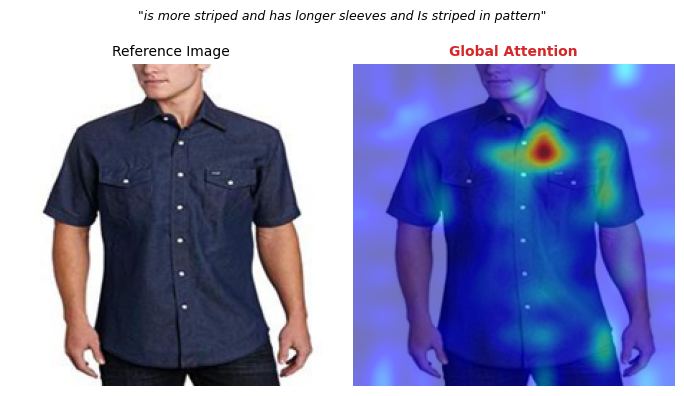

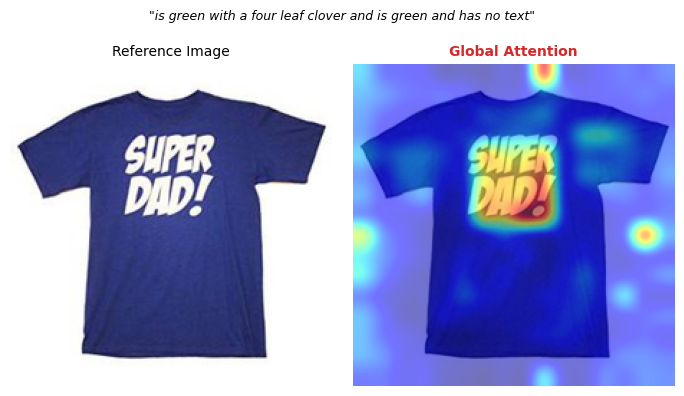

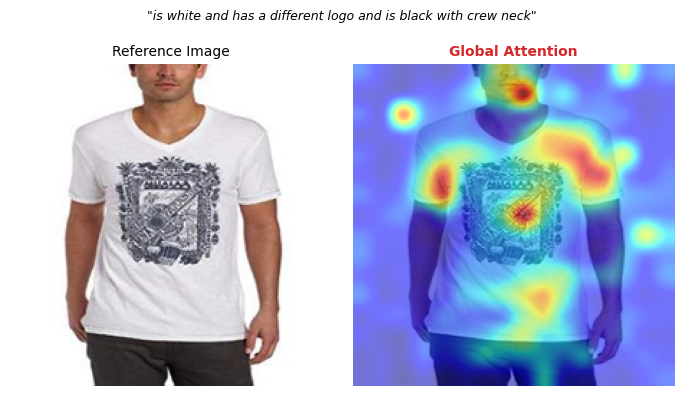

In [114]:

# Attention Maps Overlaid on Random Dataset Images


import matplotlib.cm as cm
from scipy.ndimage import gaussian_filter

@torch.no_grad()
def visualize_smooth_attention_overlay(
    combiner, clip_features, dino_patches_cache,
    text_token_cache, text_cls_cache, tokenizer, val_data,
    device, n_samples=6, grid=16, sigma=3.0,
    alpha_img=0.45, alpha_heat=0.55
):
    combiner.eval()


    candidates = []

    for cat in CATEGORIES:
        for item in val_data[cat]["captions"]:
            rid = item["candidate"]
            cap = item["captions"][0] + " and " + item["captions"][1]
            if (rid in clip_features and rid in dino_patches_cache
                    and cap in text_token_cache and cap in text_cls_cache):
                img_path = find_img(rid, IMAGE_DIR)
                if img_path:
                    candidates.append((rid, cap, img_path))

    if not candidates:
        print(" No valid samples with images found.")
        return

    random.shuffle(candidates)
    samples = candidates[:n_samples]


    for s_idx, (rid, cap, img_path) in enumerate(samples):


        txt  = text_token_cache[cap].float().unsqueeze(0).to(device)
        pat  = dino_patches_cache[rid].float().unsqueeze(0).to(device)
        rc   = clip_features[rid].unsqueeze(0).to(device)
        tcls = text_cls_cache[cap].unsqueeze(0).to(device)

        composed, pooled_out, attn_maps = combiner(
            txt, pat, rc, tcls, return_attn=True)

        attn = attn_maps[-1].squeeze(0).cpu().float()  # [77, 256]

        token_ids = tokenizer.encode(cap)
        n_valid = 0
        for pos in range(1, min(77, len(token_ids))):
            tok_id = token_ids[pos]
            if tok_id == 0 or tok_id == 49407:
                break
            n_valid += 1

        if n_valid == 0:

            continue

        global_attn = attn[1:n_valid + 1].mean(dim=0).numpy().reshape(grid, grid)


        pil_img = Image.open(img_path).convert("RGB")
        img_224 = pil_img.resize((224, 224))
        img_arr = np.array(img_224) / 255.0


        up = np.array(
            Image.fromarray(global_attn.astype(np.float32))
                 .resize((224, 224), Image.BILINEAR))
        up = gaussian_filter(up, sigma=sigma)
        mn, mx = up.min(), up.max()
        norm = (up - mn) / (mx - mn + 1e-8)
        heatmap = cm.jet(norm)[:, :, :3]
        blended = np.clip(alpha_img * img_arr + alpha_heat * heatmap, 0, 1)


        fig, axes = plt.subplots(1, 2, figsize=(7, 3.8))

        axes[0].imshow(img_arr)
        axes[0].set_title("Reference Image", fontsize=10)
        axes[0].axis("off")

        axes[1].imshow(blended)
        axes[1].set_title("Global Attention", fontsize=10,
                          fontweight="bold", color="#d62728")
        axes[1].axis("off")

        caption_display = f'"{cap[:90]}..."' if len(cap) > 90 else f'"{cap}"'
        fig.suptitle(caption_display, fontsize=9, y=1.03, style="italic")
        plt.tight_layout()


        plt.show()





visualize_smooth_attention_overlay(
    combiner, clip_features, dino_patches_cache,
    text_token_cache, text_cls_cache, tokenizer, val_data, DEVICE,
    n_samples=3,
    grid=16,
    sigma=3.0,
    alpha_img=0.45,
    alpha_heat=0.55,
)

Found 3 samples with target in top-5



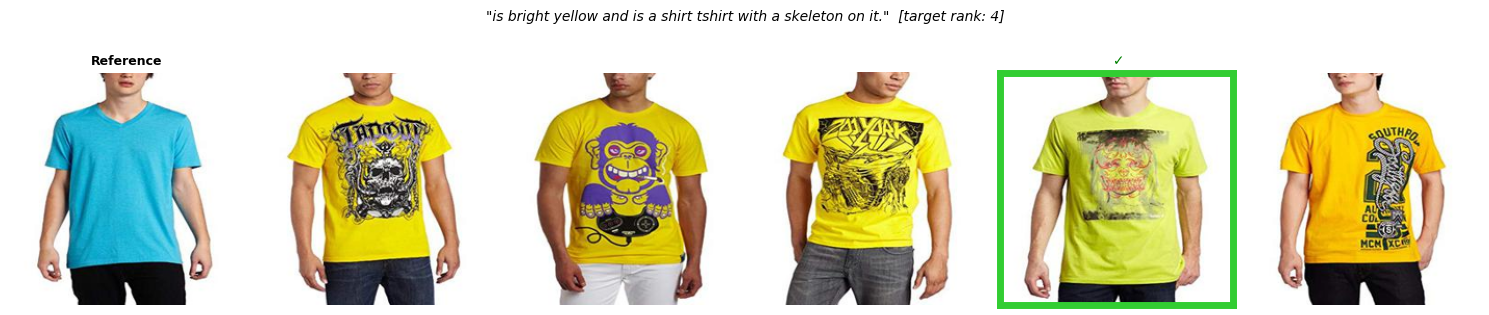

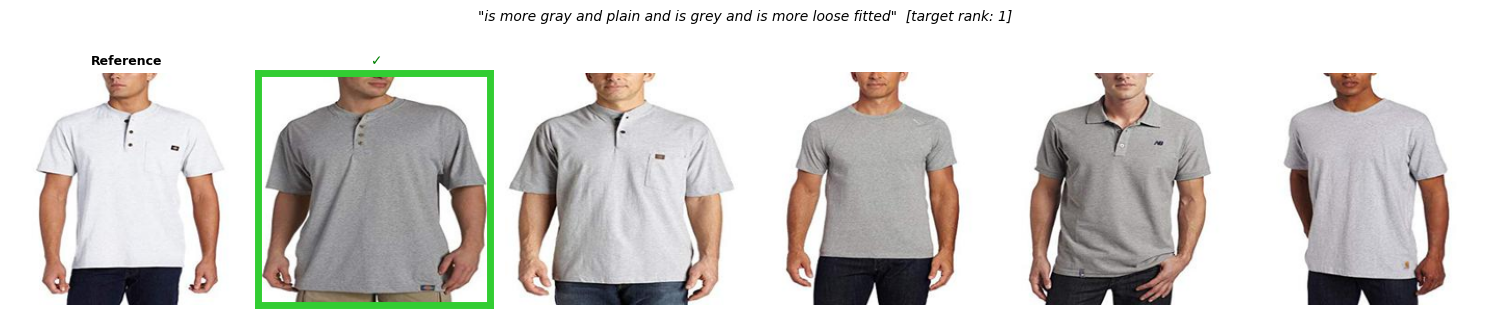

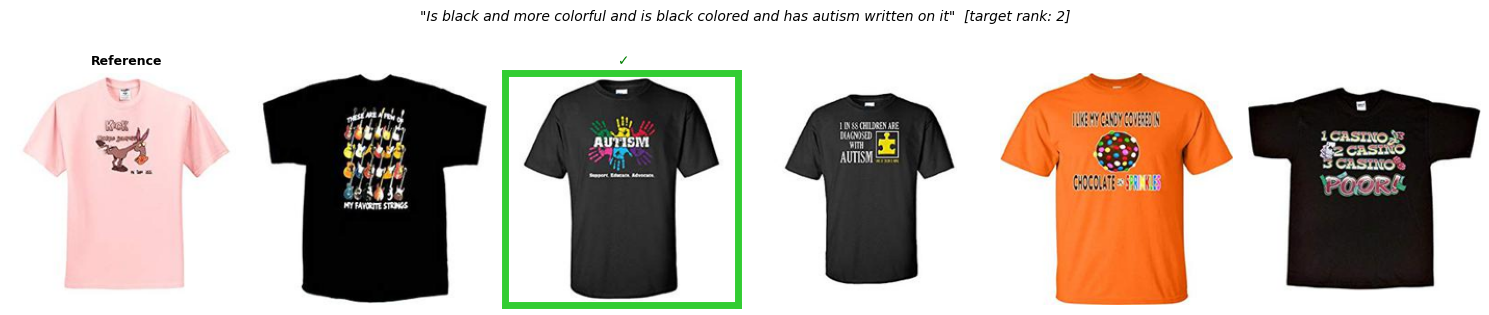

In [116]:

# Sample Retrieval Examples

@torch.no_grad()
def show_sample_retrievals(n_samples=6, top_k=10):
    combiner.eval()

    # Collect valid triplets
    candidates = []
    if DATASET == "cirr":
        for item in val_data["all"]["captions"]:
            rid, tid = item["candidate"], item["target"]
            cap = item["captions"][0]
            if (rid in clip_features and rid in dino_patches_cache
                    and cap in text_token_cache and cap in text_cls_cache
                    and tid in gallery_id2idx):
                candidates.append((rid, tid, cap))
    else:
        for cat in CATEGORIES:
            for item in val_data[cat]["captions"]:
                rid, tid = item["candidate"], item["target"]
                cap = item["captions"][0] + " and " + item["captions"][1]
                if (rid in clip_features and rid in dino_patches_cache
                        and cap in text_token_cache and cap in text_cls_cache
                        and tid in gallery_id2idx):
                    candidates.append((rid, tid, cap))

    random.shuffle(candidates)

    # Pre filter: only keep samples where target rank <= top_k
    filtered = []
    for rid, tid, cap in candidates:
        if len(filtered) >= n_samples:
            break

        txt  = text_token_cache[cap].float().unsqueeze(0).to(DEVICE)
        pat  = dino_patches_cache[rid].float().unsqueeze(0).to(DEVICE)
        rc   = clip_features[rid].unsqueeze(0).to(DEVICE)
        tcls = text_cls_cache[cap].unsqueeze(0).to(DEVICE)

        composed, _ = combiner(txt, pat, rc, tcls)
        query_feat  = F.normalize(composed, dim=-1).cpu()

        sims = (query_feat @ gallery_feats.T).squeeze(0)
        if rid in gallery_id2idx:
            sims[gallery_id2idx[rid]] = -1e9

        topk_i = sims.topk(top_k).indices.tolist()
        retrieved_ids = [gallery_ids[i] for i in topk_i]

        if tid in retrieved_ids:
            rank = retrieved_ids.index(tid) + 1
            filtered.append((rid, tid, cap, sims, rank))

    print(f"Found {len(filtered)} samples with target in top-{top_k}\n")

    for s_idx, (rid, tid, cap, sims, target_rank) in enumerate(filtered):

        topk_v, topk_i = sims.topk(top_k)
        retrieved_ids = [gallery_ids[topk_i[j].item()] for j in range(top_k)]

        ncols = 1 + top_k
        fig, axes = plt.subplots(1, ncols, figsize=(2.5 * ncols, 3))

        # Reference image
        ref_path = find_img(rid, IMAGE_DIR)
        if ref_path:
            axes[0].imshow(Image.open(ref_path).convert("RGB").resize((224, 224)))
        else:
            axes[0].text(0.5, 0.5, rid[:15], ha="center", va="center",
                         transform=axes[0].transAxes, fontsize=8)
        axes[0].set_title("Reference", fontsize=9, fontweight="bold")
        axes[0].axis("off")

        # Retrieved images
        for j in range(top_k):
            ax  = axes[j + 1]
            gid = retrieved_ids[j]
            img_path = find_img(gid, IMAGE_DIR)

            if img_path:
                ax.imshow(Image.open(img_path).convert("RGB").resize((224, 224)))
            else:
                ax.text(0.5, 0.5, gid[:15], ha="center", va="center",
                        transform=ax.transAxes, fontsize=7)

            is_target = (gid == tid)


            ax.set_xticks([])
            ax.set_yticks([])

            if is_target:
                for spine in ax.spines.values():
                    spine.set_visible(True)
                    spine.set_color("limegreen")
                    spine.set_linewidth(5)
            else:
                # Hide borders for incorrect images
                for spine in ax.spines.values():
                    spine.set_visible(False)

            label = ""
            if is_target:
                label += " ✓"

            ax.set_title(label,
                         fontsize=10,
                         color="green" if is_target else "black",
                         fontweight="bold" if is_target else "normal")



        cap_short = cap[:85] + "..." if len(cap) > 85 else cap
        fig.suptitle(f'"{cap_short}"  [target rank: {target_rank}]',
                     fontsize=10, y=1.05, style="italic")
        plt.tight_layout()
        plt.show()



show_sample_retrievals(n_samples=3, top_k=5)